## Theory¶
Unwanted substructures:
Substructures can be unfavorable, (e.g. **toxic** or **reactive**, due to unfavorable pharmacokinetic properties, or because they likely interfere with certain assays). Nowadays, drug discovery campaigns often involve high throughput screening. Filtering unwanted substructures can support assembling more efficient screening libraries, which can save time and resources.

Brenk et al. (Chem. Med. Chem. (2008), 3, 435-44) have assembled a list of unfavorable substructures to filter their libraries used to screen for compounds to treat neglected diseases. Examples of such unwanted features are nitro groups (mutagenic), sulfates and phosphates (likely resulting in unfavorable pharmacokinetic properties), 2-halopyridines and thiols (reactive). 

## Pan Assay Interference Compounds (PAINS)¶
PAINS are compounds that often occur as hits in HTS even though they actually are false positives. 
PAINS show activity at numerous targets rather than one specific target. 
Such behavior results from **unspecific binding** or **interaction with assay components**. Baell et al. (J. Med. Chem. (2010), 53, 2719-2740) focused on substructures interfering in assay signaling. They described substructures which can help to identify such PAINS and provided a list which can be used for substructure filtering.

In [1]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

In [4]:
DATA_DIR = Path("/Users/duncanfreeman/dev/bioinfo/data")

In [5]:
# load data from t002
egfr_df = pd.read_csv(DATA_DIR / "EGFR_molecules_ro5_fulfilled.csv", index_col=0)
egfr_df.head(1)

,molecule_chembl_id,IC50,units,smiles,pIC50_old,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pIC50,Ro5_fulfilled
Unnamed: 0,,,,,,,,,,,,,
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,350.219,5.2891,1,3,37.81,2,11.522879,True


In [6]:
egfr_df.columns

Index(['molecule_chembl_id', 'IC50', 'units', 'smiles', 'pIC50_old', 'MW',
       'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'RotatableBonds',
       'pIC50', 'Ro5_fulfilled'],
      dtype='str')

In [7]:
egfr_df.drop(columns=[
    'pIC50_old', 'MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'RotatableBonds'
    ], inplace=True)
egfr_df.head(1)

,molecule_chembl_id,IC50,units,smiles,pIC50,Ro5_fulfilled
Unnamed: 0,,,,,,
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,True


In [8]:
egfr_df.reset_index(inplace=True, drop=True)

In [ ]:
print()

,molecule_chembl_id,IC50,units,smiles,pIC50,Ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,True


In [ ]:
mols = [Chem.MolFromSmiles(s) for s in df['smiles'] if s is not None]
legends = df['name_column'].astype(str).tolist()

# FIX: Force legends to match molecule count
if len(legends) > len(mols):
    legends = legends[:len(mols)]
elif len(legends) < len(mols):
    legends += [""] * (len(mols) - len(legends))

img = Draw.MolsToGridImage(mols, legends=legends)


In [15]:
egfr_df.head(3)

,molecule_chembl_id,IC50,units,smiles,pIC50,Ro5_fulfilled,ROMol
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,True,<rdkit.Chem.rdchem.Mol object at 0x11656ec00>
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,True,<rdkit.Chem.rdchem.Mol object at 0x11656e8f0>
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,True,<rdkit.Chem.rdchem.Mol object at 0x11656e7a0>


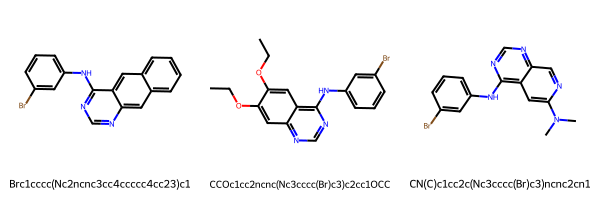

In [18]:
subset = egfr_df["smiles"].head(3)
molecules = [Chem.MolFromSmiles(s) for s in subset]
labels = subset.tolist()

Chem.Draw.MolsToGridImage(molecules, legends=labels, molsPerRow=3,subImgSize=(200, 200))

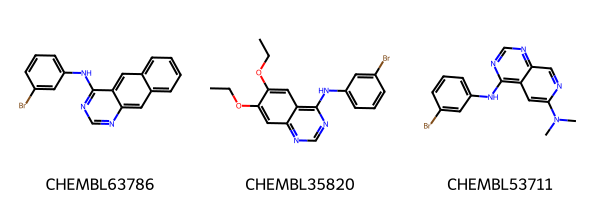

In [17]:
# Add molecule column
PandasTools.AddMoleculeColumnToFrame(egfr_df, smilesCol="smiles")
# Draw first 3 molecules
Chem.Draw.MolsToGridImage(
    list(egfr_df.head(3).ROMol),
    legends=list(egfr_df.head(3).molecule_chembl_id),
)

### Filter for PAINS

In [19]:
# initialize filter
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

In [20]:
from tqdm.auto import tqdm
# search for PAINS
matches = []
clean = []
for index, row in tqdm(egfr_df.iterrows(), total=egfr_df.shape[0]):
    molecule = Chem.MolFromSmiles(row.smiles)
    entry = catalog.GetFirstMatch(molecule)  # Get the first matching PAINS
    if entry is not None:
        # store PAINS information
        matches.append(
            {
                "chembl_id": row.molecule_chembl_id,
                "rdkit_molecule": molecule,
                "pains": entry.GetDescription().capitalize(),
            }
        )
    else:
        # collect indices of molecules without PAINS
        clean.append(index)

matches = pd.DataFrame(matches)
egfr_df = egfr_df.loc[clean]  # keep molecules without PAINS

  0%|          | 0/4661 [00:00<?, ?it/s]

In [21]:
# NBVAL_CHECK_OUTPUT
print(f"Number of compounds with PAINS: {len(matches)}")
print(f"Number of compounds without PAINS: {len(egfr_df)}")

Number of compounds with PAINS: 410
Number of compounds without PAINS: 4251


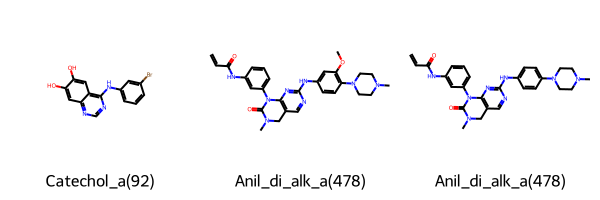

In [ ]:
# Draw first 3 molecules with PAINS
Chem.Draw.MolsToGridImage(
    list(matches.head(3).rdkit_molecule),
    legends=list(matches.head(3)["pains"]),
)

In [23]:
substructures = pd.read_csv(DATA_DIR / "unwanted_substructures.csv", sep=r"\s+")
substructures["rdkit_molecule"] = substructures.smarts.apply(Chem.MolFromSmarts)
print("Number of unwanted substructures in collection:", len(substructures))
# NBVAL_CHECK_OUTPUT

Number of unwanted substructures in collection: 105


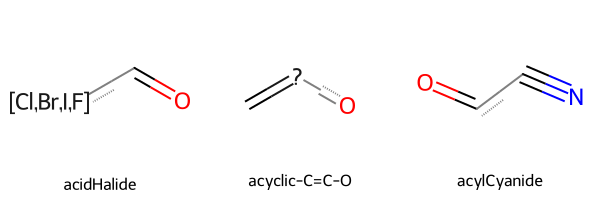

In [24]:
Chem.Draw.MolsToGridImage(
    mols=substructures.rdkit_molecule.tolist()[2:5],
    legends=substructures.name.tolist()[2:5],
)

In [25]:
substructures.head(1)

,name,smarts,rdkit_molecule
0,>2EsterGroups,"C(=O)O[C,H1].C(=O)O[C,H1].C(=O)O[C,H1]",<rdkit.Chem.rdchem.Mol object at 0x116861700>


In [26]:
patterns = list(
    substructures[["rdkit_molecule", "name"]].itertuples(index=False, name=None)
)

match_rows = []
clean_indices = []

for compound in tqdm(egfr_df[["molecule_chembl_id", "smiles"]].itertuples(), total=len(egfr_df)):
    molecule = Chem.MolFromSmiles(compound.smiles)

    if molecule is None:
        continue  # or record invalid SMILES separately

    found_match = False
    for substructure_mol, substructure_name in patterns:
        if molecule.HasSubstructMatch(substructure_mol):
            match_rows.append(
                {
                    "chembl_id": compound.molecule_chembl_id,
                    "rdkit_molecule": molecule,
                    "substructure": substructure_mol,
                    "substructure_name": substructure_name,
                }
            )
            found_match = True

    if not found_match:
        clean_indices.append(compound.Index)

matches = pd.DataFrame.from_records(match_rows)
egfr_df = egfr_df.loc[clean_indices].copy()

  0%|          | 0/4251 [00:00<?, ?it/s]

In [27]:
# NBVAL_CHECK_OUTPUT
print(f"Number of found unwanted substructure: {len(matches)}")
print(f"Number of compounds without unwanted substructure: {len(egfr_df)}")

Number of found unwanted substructure: 3261
Number of compounds without unwanted substructure: 2088


### Highlight substructures¶
Using the underlying SMARTS patterns we can highlight the substructures within the RDKit molecules.

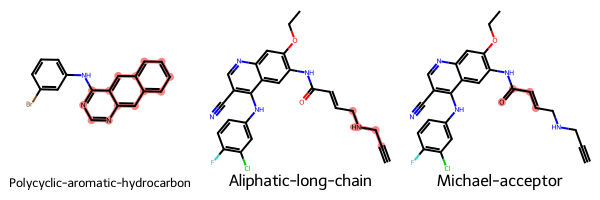

In [28]:
to_highlight = [
    row.rdkit_molecule.GetSubstructMatch(row.substructure) for _, row in matches.head(3).iterrows()
]
Chem.Draw.MolsToGridImage(
    list(matches.head(3).rdkit_molecule),
    highlightAtomLists=to_highlight,
    legends=list(matches.head(3).substructure_name),
)

### Substructure statistics¶
Find the most frequent substructure found in our data set.

In [29]:
matches.head(1)

,chembl_id,rdkit_molecule,substructure,substructure_name
0,CHEMBL63786,<rdkit.Chem.rdchem.Mol object at 0x116823d10>,<rdkit.Chem.rdchem.Mol object at 0x116863a00>,Polycyclic-aromatic-hydrocarbon


In [30]:
# NBVAL_CHECK_OUTPUT
groups = matches.groupby("substructure_name")
group_frequencies = groups.size()
group_frequencies.sort_values(ascending=False, inplace=True)
group_frequencies.head(10)

substructure_name
Michael-acceptor               1134
Aliphatic-long-chain            489
Oxygen-nitrogen-single-bond     368
triple-bond                     253
nitro-group                     178
imine                           150
Thiocarbonyl-group              114
aniline                          64
halogenated-ring                 62
conjugated-nitrile-group         59
dtype: int64

The FilterCatalog class can be used to search for predefined collections of substructures, e.g., PAINS.

The HasSubstructMatch() function to perform manual substructure searches.

Actually, PAINS filtering could also be implemented via manual substructure searches with HasSubstructMatch(). Furthermore, the substructures defined by Brenk et al. (Chem. Med. Chem. (2008), 3, 535-44) are already implemented as a FilterCatalog. Additional pre-defined collections can be found in the RDKit documentation.

So far, we have been using the HasSubstructMatch() function, which only yields one match per compound. With the GetSubstructMatches() function (documentation) we have the opportunity to identify all occurrences of a particular substructure in a compound. In case of PAINS, we have only looked at the first match per molecule (GetFirstMatch()). If we simply want to filter out all PAINS this is enough. However, we could also use GetMatches() in order to see all critical substructures of a molecule.

Detected substructures can be handled in two different fashions:

Either, the substructure search is applied as a filter and the compounds are excluded from further testing to save time and money.

Or, they can be used as warnings, since ~5 % of FDA-approved drugs were found to contain PAINS (ACS. Chem. Biol. (2018), 13, 36-44). In this case experts can judge manually, if an identified substructure is critical or not.

Quiz¶
Why should we consider removing “PAINS” from a screening library? What is the issue with these compounds?

Can you find situations when some unwanted substructures would not need to be removed?

How are the substructures we used in this tutorial encoded?